In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import scipy as sp  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import operator 
import heapq 
import warnings
warnings.filterwarnings('ignore')

In [2]:
A = np.array([[3,4]]) # Rating vector A
B = np.array([[5,2]]) # Rating vector B
cosine_similarity(A,B) # Sim(A,B)

array([[0.85419856]])

In [3]:
books = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/books_with_tags.csv')
books.head(3)

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,tag_name
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,to-read fantasy favorites currently-reading yo...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPrÃ©",1997.0,Harry Potter and the Philosopher's Stone,...,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,to-read fantasy favorites currently-reading yo...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...,to-read fantasy favorites currently-reading yo...


In [4]:
print (f'Number of books in dataset: {books.shape[0]}')

Number of books in dataset: 10000


In [5]:
book_ratings = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/book_ratings.csv')
book_ratings.head()

,user_id,book_id,title,rating
0,314,1,Harry Potter and the Half-Blood Prince (Harry ...,5
1,439,1,Harry Potter and the Half-Blood Prince (Harry ...,3
2,588,1,Harry Potter and the Half-Blood Prince (Harry ...,5
3,1169,1,Harry Potter and the Half-Blood Prince (Harry ...,4
4,1185,1,Harry Potter and the Half-Blood Prince (Harry ...,4


In [6]:
print (f'Number of ratings in dataset: {book_ratings.shape[0]}')

Number of ratings in dataset: 79701


Average rating in dataset: 3.8616453996813087


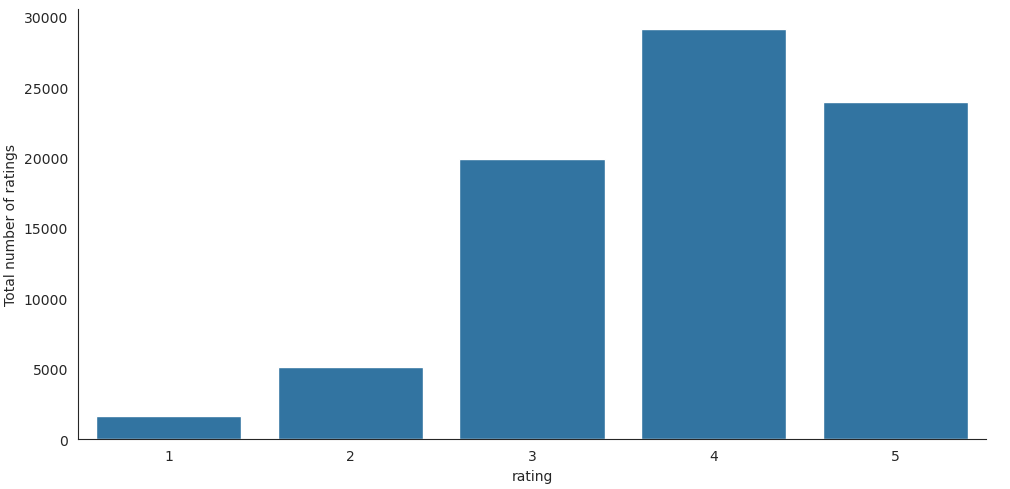

In [7]:
with sns.axes_style('white'):
    g = sns.catplot(data=book_ratings, x="rating", y=None, aspect=2.0, kind='count')
    g.set_ylabels("Total number of ratings")
print (f'Average rating in dataset: {np.mean(book_ratings["rating"])}')

In [8]:
books['auth_tags'] = (pd.Series(books[['authors', 'tag_name']]
                      .fillna('')
                      .values.tolist()).str.join(' '))

titles = books['title']
indices = pd.Series(books.index, index=books['title'])

In [9]:
tf = TfidfVectorizer(analyzer='word', ngram_range=(1,2),
                     min_df=0.0, stop_words='english')

# Produce a feature matrix, where each row corresponds to a book with TF-IDF features as columns 
tf_authTags_matrix = tf.fit_transform(books['auth_tags'])

In [10]:
cosine_sim_authTags = cosine_similarity(tf_authTags_matrix,
                                        tf_authTags_matrix)
print (cosine_sim_authTags.shape)

(10000, 10000)


In [11]:
cosine_sim_authTags[:5]

array([[1.        , 0.21246314, 0.25620534, ..., 0.04730311, 0.07394757,
        0.01578043],
       [0.21246314, 1.        , 0.20308655, ..., 0.04934816, 0.06629237,
        0.02173749],
       [0.25620534, 0.20308655, 1.        , ..., 0.03131751, 0.03967015,
        0.0137797 ],
       [0.11415006, 0.16092333, 0.10326477, ..., 0.06834212, 0.07096014,
        0.04973093],
       [0.11438683, 0.14651929, 0.1160679 , ..., 0.06632025, 0.08923058,
        0.03776143]])

In [12]:
def content_generate_top_N_recommendations(book_title, N=10):
    # Convert the string book title to a numeric index for our similarity matrix
    b_idx = indices[book_title]
    # Extract all similarity values computed with the reference book title
    sim_scores = list(enumerate(cosine_sim_authTags[b_idx]))
    # Sort the values, keeping a copy of the original index of each value
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    # Select the top-N values for recommendation
    sim_scores = sim_scores[1:N]
    # Collect indexes 
    book_indices = [i[0] for i in sim_scores]
    # Convert the indexes back into titles 
    return titles.iloc[book_indices]

In [13]:
content_generate_top_N_recommendations("The Hobbit", N=10)

188     The Lord of the Rings (The Lord of the Rings, ...
154            The Two Towers (The Lord of the Rings, #2)
160     The Return of the King (The Lord of the Rings,...
18      The Fellowship of the Ring (The Lord of the Ri...
610              The Silmarillion (Middle-Earth Universe)
4975        Unfinished Tales of NÃºmenor and Middle-Earth
2308                               The Children of HÃºrin
963     J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...
465                             The Hobbit: Graphic Novel
Name: title, dtype: object

In [14]:
content_generate_top_N_recommendations("Romeo and Juliet", N=10)

352                      Othello
769                Julius Caesar
124                       Hamlet
153                      Macbeth
247    A Midsummer Night's Dream
838       The Merchant of Venice
854                Twelfth Night
529       Much Ado About Nothing
713                    King Lear
Name: title, dtype: object

In [15]:
content_generate_top_N_recommendations("The Diary of a Young Girl", N=10)

86                           Night (The Night Trilogy #1)
178                    Angela's Ashes (Frank McCourt, #1)
799                                  The Story of My Life
1814    Anne Frank Remembered: The Story of the Woman ...
512     The Hiding Place: The Triumphant True Story of...
6546                        I Have Lived a Thousand Years
8027             Anne Frank's Tales from the Secret Annex
89                                          The Outsiders
603                                     Girl, Interrupted
Name: title, dtype: object

In [16]:
def content_generate_rating_estimate(book_title, user, rating_data, k=20, threshold=0.0):
    # Convert the book title to a numeric index for our similarity matrix
    b_idx = indices[book_title]
    neighbors = []  

    # Gather the similarity ratings between each book the user has rated and the reference book 
    for index, row in rating_data[rating_data['user_id']==user].iterrows():
        sim = cosine_sim_authTags[b_idx-1, indices[row['title']]-1]
        neighbors.append((sim, row['rating']))
    # Select the top-N values from our collection
    k_neighbors = heapq.nlargest(k, neighbors, key=lambda t: t[0])

    # Compute the weighted average using similarity scores and  user item ratings. 
    simTotal, weightedSum = 0, 0
    for (simScore, rating) in k_neighbors:
        # Ensure that similarity ratings are above a given threshold
        if (simScore > threshold):
            simTotal += simScore
            weightedSum += simScore * rating
    try:
        predictedRating = weightedSum / simTotal
    except ZeroDivisionError:
        # Cold-start problem - No ratings given by user. 
        # We use the average rating for the reference item as a proxy in this case 
        predictedRating = np.mean(rating_data[rating_data['title']==book_title]['rating'])
    return predictedRating

In [17]:
# Subset of ratings from user 314
book_ratings[book_ratings['user_id'] == 314][3:10]

,user_id,book_id,title,rating
401,314,6,Harry Potter and the Goblet of Fire (Harry Pot...,5
1500,314,29,The Mother Tongue: English and How It Got That...,3
1600,314,30,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,4
1900,314,36,The Lord of the Rings: Weapons and Warfare,4
2300,314,98,What to Expect the First Year (What to Expect),3
2400,314,105,Chapterhouse: Dune (Dune Chronicles #6),3
2501,314,106,Dune Messiah (Dune Chronicles #2),4


In [18]:
title = "The Lord of the Rings: Weapons and Warfare"
actual_rating = book_ratings[(book_ratings['user_id'] == 314) & (book_ratings['title'] == title)]['rating'].values[0]
pred_rating = content_generate_rating_estimate(book_title=title, user=314, rating_data=book_ratings)
print (f"Title - {title}")
print ("---")
print (f"Actual rating: \t\t {actual_rating}")
print (f"Predicted rating: \t {pred_rating}")

Title - The Lord of the Rings: Weapons and Warfare
---
Actual rating: 		 4
Predicted rating: 	 3.82672277262443


In [19]:
title = "Survival in Auschwitz"
actual_rating = book_ratings[(book_ratings['user_id'] == 314) & (book_ratings['title'] == title)]['rating'].values[0]
pred_rating = content_generate_rating_estimate(book_title=title, user=314, rating_data=book_ratings)
print (f"Title - {title}")
print ("---")
print (f"Actual rating: \t\t {actual_rating}")
print (f"Predicted rating: \t {pred_rating}")

Title - Survival in Auschwitz
---
Actual rating: 		 2
Predicted rating: 	 2.798414160445382


In [22]:
title = "The Hobbit"
pred_rating = content_generate_rating_estimate(book_title=title, user=314, rating_data=book_ratings)
print (f"Title - {title}")
print ("---")
print (f"Actual rating: \t\t {actual_rating}")
print (f"Predicted rating: \t {pred_rating}")

Title - The Hobbit
---
Actual rating: 		 2
Predicted rating: 	 3.57483886978633


In [23]:
title = "Dune (Dune Chronicles #1)"
pred_rating = content_generate_rating_estimate(book_title=title, user=314, rating_data=book_ratings)
print (f"Title - {title}")
print ("---")
print (f"Actual rating: \t\t {actual_rating}")
print (f"Predicted rating: \t {pred_rating}")

Title - Dune (Dune Chronicles #1)
---
Actual rating: 		 2
Predicted rating: 	 3.7612070634075323
